In [2]:
# 1. Clean numerical columns (remove commas and convert to numbers)
num_cols = [
    'Tourists Number (Overnight Visitors) (000)',
    'Overnight Stay (000)',
    'Tourists Spending (SAR Mn)'
]

for col in num_cols:
    # Remove commas and convert text to float numbers
    df[col] = df[col].astype(str).str.replace(',', '').astype(float)

# 2. Plot a Line Chart showing Tourist Spending over Years
plt.figure(figsize=(10, 5))
sns.lineplot(data=df, x='YEARS', y='Tourists Spending (SAR Mn)', marker='o', color='green', linewidth=2.5)

# Add titles and labels for a clean report look
plt.title('Riyadh Inbound Tourist Spending Trend (2015-2024)', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Tourists Spending (SAR Millions)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

# Display chart
plt.show()

KeyError: 'Tourists Number (Overnight Visitors) (000)'

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Notice 'Saudi Arabia/' is included because it's inside that folder!
file_path = 'Saudi Arabia/Riyadh Inbound2024Tourism Indicators Spending CSV.csv'
df = pd.read_csv(file_path)

# Check the structure
print("--- DATASET SHAPE ---")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}\n")

# Display first 5 rows
display(df.head())

# 3. Check data types and missing values
print("--- DATASET INFO ---")
df.info()

--- DATASET SHAPE ---
Rows: 30, Columns: 8



,DESTINATION,YEARS,Tourists Number (Overnight Visitors) (000),Overnight Stay (000),Tourists Spending (SAR Mn),Average Length of Stay (Night),Avergae Spending per Trip (SAR),Average Spending per Night (SAR)
0,Riyadh Province,2015,"2,021","8,639","9,897",4.3,"4,897","1,146"
1,Riyadh Province,2016,"3,242","14,918","20,739",4.6,"6,396","1,390"
2,Riyadh Province,2017,"1,998","8,922","12,849",4.5,"6,430","1,440"
3,Riyadh Province,2018,"2,010","10,147","12,021",5.1,"5,980","1,185"
4,Riyadh Province,2019,"2,933","19,719","16,943",6.7,"5,777",859


--- DATASET INFO ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 8 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0    DESTINATION                                  30 non-null     object 
 1    YEARS                                        30 non-null     int64  
 2    Tourists Number (Overnight Visitors) (000)   30 non-null     object 
 3    Overnight Stay (000)                         30 non-null     object 
 4    Tourists Spending (SAR Mn)                   30 non-null     object 
 5    Average Length of Stay (Night)               30 non-null     float64
 6    Avergae Spending per Trip (SAR)              30 non-null     object 
 7    Average Spending per Night (SAR)             30 non-null     object 
dtypes: float64(1), int64(1), object(6)
memory usage: 2.0+ KB


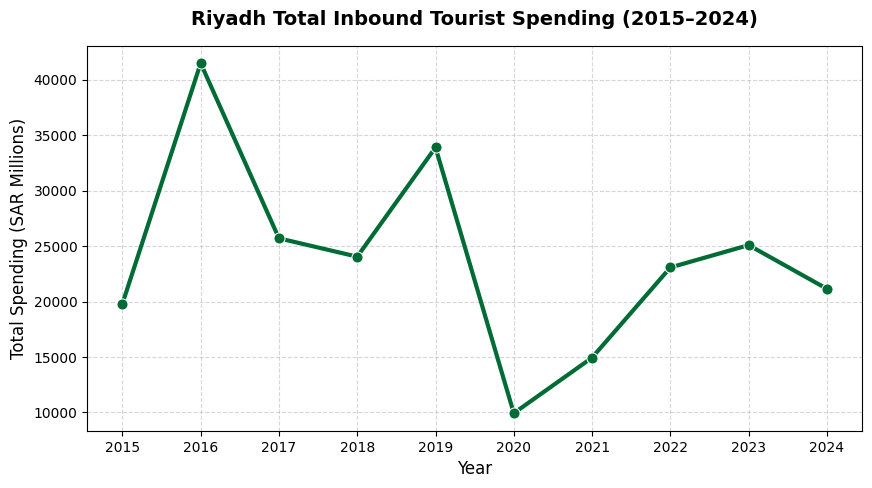

--- PORTFOLIO KEY TAKEAWAYS ---
1. Lowest spending occurred in 2020 (SAR 9,934.00 Million) due to global travel restrictions.
2. Post-COVID recovery reached peak spending in 2023 (SAR 25,084.00 Million).
3. Overall Post-COVID Growth Rate (2020 to 2023): +152.5%


In [4]:
# 1. Group by YEAR to get total annual spending (removes shaded confidence interval)
yearly_spending = df.groupby('YEARS')['Tourists Spending (SAR Mn)'].sum().reset_index()

# 2. Plot clean line chart
plt.figure(figsize=(10, 5))
sns.lineplot(data=yearly_spending, x='YEARS', y='Tourists Spending (SAR Mn)', marker='o', color='#006C35', linewidth=3, markersize=8)

plt.title('Riyadh Total Inbound Tourist Spending (2015–2024)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Total Spending (SAR Millions)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(yearly_spending['YEARS']) # Show every year on x-axis

plt.show()

# 3. Calculate key insights for your portfolio write-up
spending_2020 = yearly_spending[yearly_spending['YEARS'] == 2020]['Tourists Spending (SAR Mn)'].values[0]
spending_2023 = yearly_spending[yearly_spending['YEARS'] == 2023]['Tourists Spending (SAR Mn)'].values[0]
recovery_growth = ((spending_2023 - spending_2020) / spending_2020) * 100

print("--- PORTFOLIO KEY TAKEAWAYS ---")
print(f"1. Lowest spending occurred in 2020 (SAR {spending_2020:,.2f} Million) due to global travel restrictions.")
print(f"2. Post-COVID recovery reached peak spending in 2023 (SAR {spending_2023:,.2f} Million).")
print(f"3. Overall Post-COVID Growth Rate (2020 to 2023): +{recovery_growth:.1f}%")

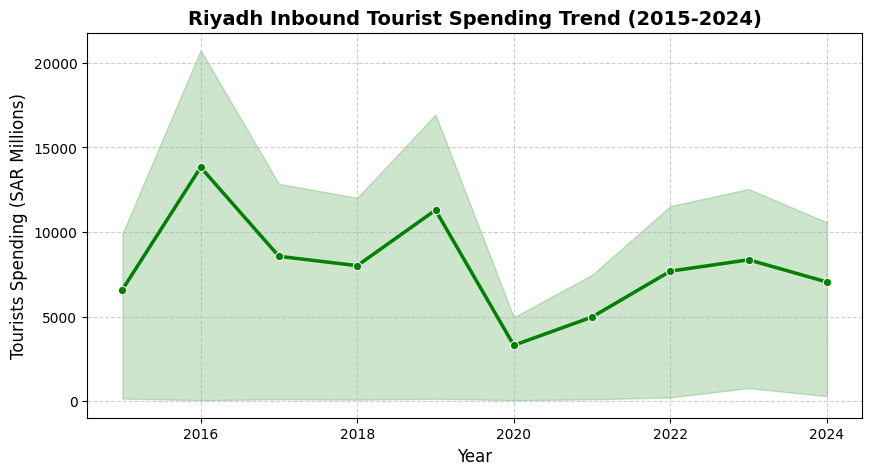

In [3]:
# 1. Clean column names to remove any accidental spaces
df.columns = df.columns.str.strip()

# 2. Select numeric columns using exact position (indices 2, 3, 4)
num_cols = df.columns[2:5]

# 3. Clean numbers (remove commas and convert to float)
for col in num_cols:
    df[col] = df[col].astype(str).str.replace(',', '').astype(float)

# 4. Plot the Spending Trend Line Chart
plt.figure(figsize=(10, 5))
sns.lineplot(data=df, x='YEARS', y='Tourists Spending (SAR Mn)', marker='o', color='green', linewidth=2.5)

# Add title and labels
plt.title('Riyadh Inbound Tourist Spending Trend (2015-2024)', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Tourists Spending (SAR Millions)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

# Display chart
plt.show()

In [5]:
# 1. Save the cleaned DataFrame to a new CSV file
df.to_csv('Saudi_Arabia/Cleaned_Riyadh_Tourism_Data.csv', index=False)

# 2. Save the line chart as a high-resolution PNG image
plt.figure(figsize=(10, 5))
sns.lineplot(data=yearly_spending, x='YEARS', y='Tourists Spending (SAR Mn)', marker='o', color='#006C35', linewidth=3)
plt.title('Riyadh Total Inbound Tourist Spending (2015–2024)', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Total Spending (SAR Millions)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.savefig('riyadh_tourism_spending_trend.png', dpi=300, bbox_inches='tight')

print("Files saved successfully! Check your left panel folder.")

OSError: Cannot save file into a non-existent directory: 'Saudi_Arabia'

Files saved successfully! Check your left panel folder.


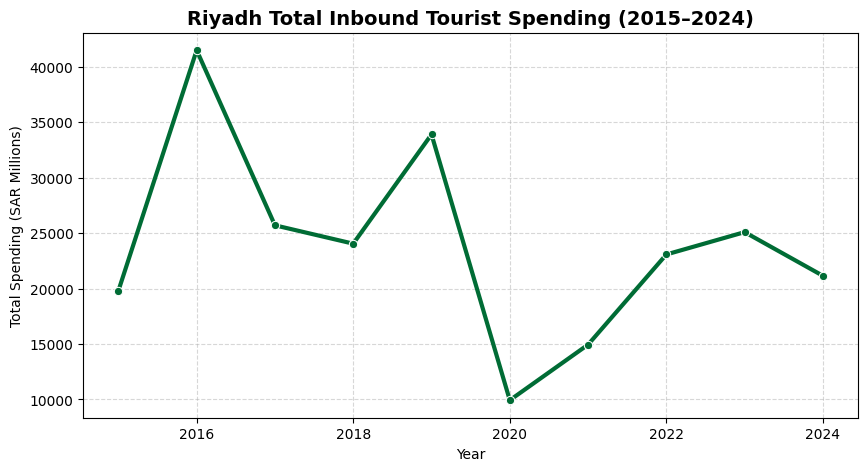

In [6]:
import os

# 1. Create the directory automatically if it doesn't exist
os.makedirs('Saudi Arabia', exist_ok=True)

# 2. Save the cleaned DataFrame to the CSV file (using space in folder name)
df.to_csv('Saudi Arabia/Cleaned_Riyadh_Tourism_Data.csv', index=False)

# 3. Save the line chart as a high-resolution PNG image
plt.figure(figsize=(10, 5))
sns.lineplot(data=yearly_spending, x='YEARS', y='Tourists Spending (SAR Mn)', marker='o', color='#006C35', linewidth=3)
plt.title('Riyadh Total Inbound Tourist Spending (2015–2024)', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Total Spending (SAR Millions)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.savefig('riyadh_tourism_spending_trend.png', dpi=300, bbox_inches='tight')

print("Files saved successfully! Check your left panel folder.")